# Kernel Ridge Regression with gaussx

A minimal kernel regression example showing how gaussx handles
the core linear algebra: solving $(K + \sigma^2 I) \alpha = y$
and computing the log-marginal likelihood.

This is the computational backbone of Gaussian process regression.

## Background

Gaussian process (GP) regression is a Bayesian nonparametric method for
function estimation. The key idea is to place a GP prior over the space
of functions, observe noisy evaluations of the function at a finite set
of inputs, and then condition on the data to obtain a posterior process.
Because the GP prior is conjugate with Gaussian observation noise, the
posterior is again a GP and can be computed in closed form.

Given training inputs $X$ with observations $y$ and test inputs $X_*$,
the posterior predictive distribution is

$$\mu_* = K_{*f}(K_{ff} + \sigma^2 I)^{-1} y$$

$$\Sigma_* = K_{**} - K_{*f}(K_{ff} + \sigma^2 I)^{-1} K_{f*}$$

where $K_{ff}$ is the kernel matrix evaluated at training points,
$K_{*f}$ is the cross-covariance between test and training points,
$K_{**}$ is the kernel at test points, and $\sigma^2$ is the
observation noise variance.

The computational bottleneck is solving the kernel system
$(K_{ff} + \sigma^2 I) \alpha = y$ and computing the log-determinant
$\log|K_{ff} + \sigma^2 I|$, both of which appear in the
log-marginal likelihood. For $n$ training points, naive dense
approaches cost $O(n^3)$; structured kernels and iterative solvers
can reduce this substantially. See Rasmussen & Williams (2006), Ch. 2
for a thorough treatment.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Generate data

A simple 1D regression problem: noisy samples from a smooth function.

In [2]:
key = jax.random.PRNGKey(42)
n_train = 50
n_test = 200
noise_std = 0.2

# True function
f_true = lambda x: jnp.sin(3 * x) * jnp.exp(-0.5 * x**2)

# Training data
x_train = jax.random.uniform(key, (n_train,), minval=-3.0, maxval=3.0)
x_train = jnp.sort(x_train)
y_train = f_true(x_train) + noise_std * jax.random.normal(
    jax.random.PRNGKey(1), (n_train,)
)

# Test grid
x_test = jnp.linspace(-3.5, 3.5, n_test)

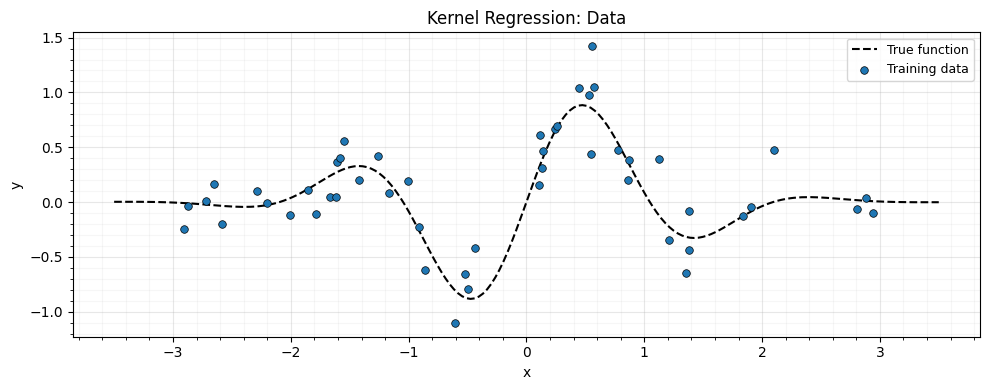

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_test, f_true(x_test), "k--", lw=1.5, zorder=4, label="True function")
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="C0",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="Training data",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
ax.set_title("Kernel Regression: Data")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Build the kernel matrix

We use a squared-exponential (RBF) kernel:

$$k(x, x') = \sigma_f^2 \exp\left(-\frac{(x - x')^2}{2 \ell^2}\right)$$

In [4]:
def rbf_kernel(x1, x2, lengthscale, variance):
    """Squared-exponential kernel matrix."""
    sq_dist = (x1[:, None] - x2[None, :]) ** 2
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale**2)


# Hyperparameters
lengthscale = 0.8
variance = 1.0
noise_var = noise_std**2

# Kernel matrices
K_train = rbf_kernel(x_train, x_train, lengthscale, variance)
K_test_train = rbf_kernel(x_test, x_train, lengthscale, variance)

## Solve with gaussx

The key computation: $(K + \sigma^2 I) \alpha = y$.

We wrap the kernel matrix as a lineax operator and use
`gaussx.solve` which dispatches to the appropriate solver.

In [5]:
# K + noise * I as a LowRankUpdate? No -- this is dense.
# Wrap as a MatrixLinearOperator with PSD tag.
K_noisy = K_train + noise_var * jnp.eye(n_train)
op = lx.MatrixLinearOperator(K_noisy, lx.positive_semidefinite_tag)

# Solve for weights
alpha = gaussx.solve(op, y_train)

# Predict
y_pred = K_test_train @ alpha

print("alpha shape:", alpha.shape)
print("prediction shape:", y_pred.shape)

alpha shape: (50,)
prediction shape: (200,)


## Log-marginal likelihood

$$\log p(y | X, \theta) = -\frac{1}{2} y^\top (K + \sigma^2 I)^{-1} y
                          - \frac{1}{2} \log |K + \sigma^2 I|
                          - \frac{n}{2} \log 2\pi$$

In [6]:
def log_marginal_likelihood(y, op):
    """GP log-marginal likelihood."""
    alpha = gaussx.solve(op, y)
    data_fit = -0.5 * jnp.dot(y, alpha)
    complexity = -0.5 * gaussx.logdet(op)
    constant = -0.5 * y.shape[0] * jnp.log(2 * jnp.pi)
    return data_fit + complexity + constant


lml = log_marginal_likelihood(y_train, op)
print(f"Log-marginal likelihood: {lml:.4f}")

Log-marginal likelihood: -18.2919


## Optimizing hyperparameters with grad

gaussx primitives are differentiable. We can optimize
hyperparameters via gradient descent on the negative log-marginal
likelihood.

The analytic gradient of the log-marginal likelihood with respect to
a hyperparameter $\theta_j$ is

$$\frac{\partial}{\partial \theta_j} \log p(y|X,\theta)
= \frac{1}{2} \alpha^\top \frac{\partial K}{\partial \theta_j} \alpha
- \frac{1}{2} \operatorname{tr}\!\left(K^{-1}
\frac{\partial K}{\partial \theta_j}\right)$$

where $\alpha = K_y^{-1} y$ and $K_y = K + \sigma^2 I$.
The first term rewards data fit and the second penalizes model
complexity (Rasmussen & Williams, 2006, Eq. 5.9).

Rather than implementing this expression manually, gaussx + JAX
computes the gradient via automatic differentiation through `solve`
and `logdet`. This is both simpler and less error-prone.

In [7]:
def neg_lml(log_params):
    """Negative log-marginal likelihood as a function of log-hyperparameters."""
    ls = jnp.exp(log_params[0])
    var = jnp.exp(log_params[1])
    noise = jnp.exp(log_params[2])

    K = rbf_kernel(x_train, x_train, ls, var) + noise * jnp.eye(n_train)
    op = lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)
    return -log_marginal_likelihood(y_train, op)


# Initial log-hyperparameters
log_params = jnp.log(jnp.array([lengthscale, variance, noise_var]))

# Gradient
grad_fn = jax.grad(neg_lml)
g = grad_fn(log_params)
print("Gradient of neg-LML:", g)

# Simple gradient descent (a few steps)
lr = 0.1
for _i in range(20):
    g = grad_fn(log_params)
    log_params = log_params - lr * g

optimized = jnp.exp(log_params)
print(
    f"\nOptimized: lengthscale={optimized[0]:.3f}, "
    f"variance={optimized[1]:.3f}, noise={optimized[2]:.4f}"
)

Gradient of neg-LML: [36.22926626 -2.36412712 -6.9243587 ]



Optimized: lengthscale=0.388, variance=0.177, noise=0.0522


## Prediction with optimized hyperparameters

In [8]:
ls_opt, var_opt, noise_opt = jnp.exp(log_params)
K_opt = rbf_kernel(x_train, x_train, ls_opt, var_opt) + noise_opt * jnp.eye(n_train)
op_opt = lx.MatrixLinearOperator(K_opt, lx.positive_semidefinite_tag)
alpha_opt = gaussx.solve(op_opt, y_train)

K_star = rbf_kernel(x_test, x_train, ls_opt, var_opt)
y_pred_opt = K_star @ alpha_opt

# Predictive variance
# solve is vector-valued, so use vmap to solve for each test point
K_ss_diag = var_opt * jnp.ones(n_test)  # diagonal of K_**
V = jax.vmap(lambda k: gaussx.solve(op_opt, k))(K_star)  # (n_test, n_train)
y_var = K_ss_diag - jnp.sum(K_star * V, axis=1)
y_std = jnp.sqrt(jnp.maximum(y_var, 0.0))

print(f"Mean prediction range: [{y_pred_opt.min():.2f}, {y_pred_opt.max():.2f}]")
print(f"Mean std range: [{y_std.min():.4f}, {y_std.max():.4f}]")

Mean prediction range: [-0.72, 0.90]
Mean std range: [0.0855, 0.3984]


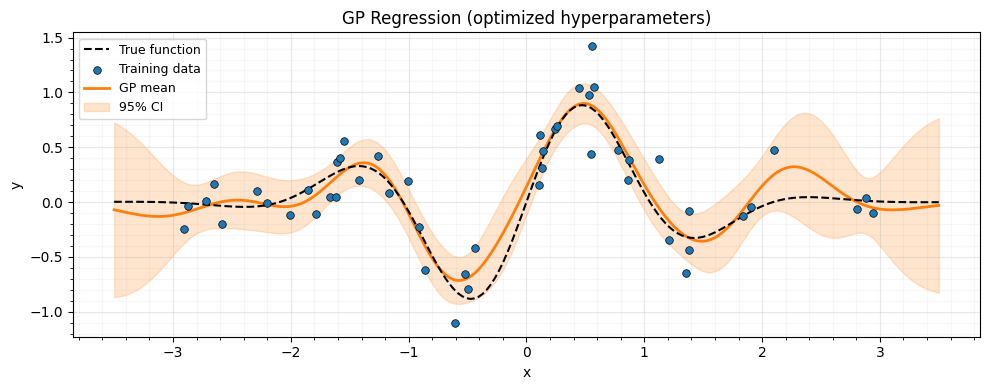

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_test, f_true(x_test), "k--", lw=1.5, zorder=4, label="True function")
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="C0",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="Training data",
)
ax.plot(x_test, y_pred_opt, "C1-", lw=2, zorder=3, label="GP mean")
ax.fill_between(
    x_test,
    y_pred_opt - 2 * y_std,
    y_pred_opt + 2 * y_std,
    alpha=0.2,
    color="C1",
    label="95% CI",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
ax.set_title("GP Regression (optimized hyperparameters)")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Summary

This example showed how gaussx provides the core linear algebra for GP regression:

1. **`gaussx.solve`** — solve the kernel system for weights
2. **`gaussx.logdet`** — log-determinant for the marginal likelihood
3. **`jax.grad`** — differentiate through both to optimize hyperparameters

For large-scale problems, the same code works with structured kernels
(Kronecker for grid data, low-rank for inducing points) — gaussx
automatically dispatches to the efficient algorithm.

## References

- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes
  for Machine Learning*. MIT Press.
- Williams, C. K. I. & Rasmussen, C. E. (1996). Gaussian processes
  for regression. *Proc. NeurIPS 8*.